**Connection to personal Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics
import os
!pip install catboost
from IPython.display import display
import ipywidgets as widgets
from joblib import dump

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.7 MB/s eta 0:00:00


**Path to data set up**

In [18]:
# Inserire il proprio path
ROOT_PATH   = "/content/drive/My Drive/"
print(f'root path is {ROOT_PATH}')
os.listdir(ROOT_PATH)
train_type = '' #SERVE SOLO PER IL NOME CON CUI VENGONO SALVATE LE VARIE COSE
#DATA_FOLDER = os.path.join(ROOT_PATH, "BHI2023/data/PilotCursiveDataTrain_" + str(num_pilot_data) + "/")
DATA_FOLDER = os.path.join(ROOT_PATH, "TesiTriennaleAnziani/Indicatori/")
#path = os.path.join(ROOT_PATH, "BHI2023/")
path = os.path.join(ROOT_PATH, "TesiTriennaleAnziani/")
print(f'data folder is {DATA_FOLDER}')
files = os.listdir(DATA_FOLDER) #elenca elementi nella cartella
print(f'files in data folder are {files}')

root path is /content/drive/My Drive/
data folder is /content/drive/My Drive/TesiTriennaleAnziani/Indicatori/
files in data folder are ['Spirale_others.xlsx', 'TabellaSpiral.xlsx', 'TabellaSentenceCapitals.xlsx', 'Copia di TabellaSentenceCursive.xlsx']


**Select file to read**

In [19]:
# creates interactive window where to enter a number between 0 and len(files)-1
# according to selected number, the corresponding file in data folder is selected
bounded_int_text = widgets.BoundedIntText(
    value=0,
    min=0,
    max=len(files)-1,
    step=1,
    description='Enter file number:',
    disabled=False
)

# Display the BoundedIntText widget
display(bounded_int_text)

# Function to handle the input and assign it to a variable
def handle_bounded_int_input(change):
    global numeric_value
    numeric_value = change.new
    print(f'The entered integer value is: {numeric_value}')

# Attach the function to the widget
bounded_int_text.observe(handle_bounded_int_input, names='value')


BoundedIntText(value=0, description='Enter file number:', max=3)

The entered integer value is: 1
The entered integer value is: 3
The entered integer value is: 2
The entered integer value is: 0
The entered integer value is: 1
The entered integer value is: 3
The entered integer value is: 2
The entered integer value is: 1
The entered integer value is: 0
The entered integer value is: 1
The entered integer value is: 0
The entered integer value is: 1


In [35]:
print(f'selected file is {files[numeric_value]}')
# read data from excel file as data frame
data1 = pd.read_excel(DATA_FOLDER + files[numeric_value]) #mettere data1 nel caso della spirale

selected file is TabellaSpiral.xlsx


In [36]:
#NO PER FRASI
bounded_int_text = widgets.BoundedIntText(
    value=0,
    min=0,
    max=len(files)-1,
    step=1,
    description='Enter file number:',
    disabled=False
)

# Display the BoundedIntText widget
display(bounded_int_text)

# Function to handle the input and assign it to a variable
def handle_bounded_int_input(change):
    global numeric_value
    numeric_value = change.new
    print(f'The entered integer value is: {numeric_value}')

# Attach the function to the widget
bounded_int_text.observe(handle_bounded_int_input, names='value')


BoundedIntText(value=0, description='Enter file number:', max=3)

The entered integer value is: 1
The entered integer value is: 0


In [37]:
print(f'selected file is {files[numeric_value]}')
# read data from excel file as data frame
data2 = pd.read_excel(DATA_FOLDER + files[numeric_value])

selected file is Spirale_others.xlsx


In [38]:
# NO PER FRASI
#extract data from onboard task
num_pilot_data = 3
data2 = data2.groupby('subject').head(num_pilot_data) # we consider at most num_pilot_data for every patient in data2

In [39]:
data = pd.concat([data1, data2])

In [40]:
data.shape

(371, 223)

**Data organization**

In [22]:
# flags for data resampling and aggregation
resample = False # if true we apply an undersampling tecnique in order to avoid class imbalance
group_per_user = False

In [23]:
# data index organization
data.reset_index(drop=True, inplace=True)
print(f'data frame original dimension is {data.shape}')

data frame original dimension is (307, 223)


In [24]:
# drop rows with null value in MMSE
data=data.dropna(subset=['MMSE'])
print(f'data frame shape after dropping unwanted rows is {data.shape}')
print(data['MMSE'].isna().sum())  # (every row in our dataset has a label)

data frame shape after dropping unwanted rows is (302, 223)
0


In [25]:
#drop categorical features we are not interested in
data.drop(['MMSE_age_adj', 'age', 'years_education', 'subject', 'MMSE_post'], axis=1, inplace=True)
print(f'data frame shape after dropping unwanted columns is {data.shape}')

data frame shape after dropping unwanted columns is (302, 218)


In [26]:
# drop columns with at least one NaN value
data.dropna(axis=1,inplace=True)
data.reset_index(drop=True, inplace=True)

print(f'data frame shape after dropping NaN columns is {data.shape}')

data frame shape after dropping NaN columns is (302, 208)


In [ ]:
data.head()

,ExecutionTime,StrokeNum,RelStrokeNum,meanOnsheet,OnSheetRatio,Inair_nopause_CV,meanPause,Pause_CV,PauseNum,PauseNum_Rel,...,median_G_PC1_new,median_G_PC_sum_new,median_G_PC_new,median_G_tr_dominant_new,median_TILT,RPW_Fra_median,RPW_Fra_median_new,RPW_Fra_Sara_mean,RPW_Fra_PC,MMSE
0,32.54,1,0.030731,32.54,1.000000,0.0,0.0,0.0,0,0.0,...,6.5,6.1,6.1,6.2,0.0,0.149915,0.164126,0.148723,0.182948,28.0
1,24.56,1,0.040717,24.56,1.000000,0.0,0.0,0.0,0,0.0,...,5.8,5.3,5.3,5.3,0.0,0.185365,0.185365,0.165881,0.112648,28.0
2,26.52,1,0.037707,26.52,1.000000,0.0,0.0,0.0,0,0.0,...,6.6,6.3,6.6,6.5,0.0,0.132958,0.132958,0.135049,0.131515,28.0
3,21.46,2,0.093197,10.71,0.998136,0.0,0.0,0.0,0,0.0,...,6.4,6.6,6.6,6.0,0.0,0.084075,0.149483,0.110274,0.192701,28.0
4,22.60,1,0.044248,22.60,1.000000,0.0,0.0,0.0,0,0.0,...,7.0,7.1,7.1,7.1,0.0,0.233478,0.197269,0.197092,0.231298,28.0


**Label creation according to MMSE value**

In [27]:
# create label and add it to data frame
label = [0 if x  > 28 else 1 for x in data['MMSE']]  # list comprehension iterating trough the MMSE column in data
data['label'] = label  # adding the label column in data

# drop MMSE feature we are not interested in
data.drop(['MMSE'], axis=1, inplace=True)
data.reset_index(drop=True, inplace=True)
data['label'].value_counts()
model_name ='all'

In [28]:
# Contare le occorrenze di ogni label (0 e 1)
label_counts = data['label'].value_counts()

# Visualizzare i risultati
print(label_counts)


label
0    196
1    106
Name: count, dtype: int64


**NUMERICAL FEATURE DROP. EACH CELL DROPS DIFFERENT FEATURE COMBINATION**

In [14]:
#NO per spirale
column_name = 'S1_median'
column_index = data.columns.get_loc(column_name)
print(column_index)

35


In [15]:
#NO per spirale
#Drop based on my interpretation -> only TIME features
#drop TREMOR features
data = data.drop(data.iloc[:, column_index:-1], axis=1)
#drop EXECUTION TIME and STROKE NUMBER
model_name = 'Time' #SERVE SOLO PER IL NOME CON CUI VENGONO SALVATE LE VARIE COSE
print(data.shape)


(265, 36)


In [ ]:
'''
#Drop based on my interpretation -> only TIME features, without:
#execution time, stroke number, pause related feature (as free text is included in the model)
#drop TREMOR features
data = data.drop(data.iloc[:, 38:-1], axis=1)
#drop EXECUTION TIME and STROKE NUMBER
data = data.drop(data.iloc[:, 0:2], axis=1)
#drop features related to PAUSES
data = data.drop(columns = ['meanInair', 'Inair_CV', 'meanPause', 'Pause_CV', 'PauseNum', 'PauseNum_Rel', 'AirSheet_Ratio_pause'])
model_name = 'TimeNoPause'
'''

KeyError: "['meanInair', 'Inair_CV', 'AirSheet_Ratio_pause'] not found in axis"

**Encode features and label**

In [16]:
# separate features and label
X = data.iloc[:, :-1] # features (ignoring data last column)
y = data.iloc[:, -1] # labels
print(f'X shape is {X.shape}')
print(f'y shape is {y.shape}')
X.reset_index(inplace=True, drop=True)
y.reset_index(inplace=True, drop=True)

# here X nd y are still dataframe

X shape is (265, 35)
y shape is (265,)


In [ ]:
# encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)  # here y is a ndarray (equivalent numpy of a list)
classes, n_classes =np.unique(y, return_counts=True)
print(f'Classes are {classes}. Classes cardinality is {n_classes}')

Classes are [0 1]. Classes cardinality is [196 106]


**Import for machine learning processing**

In [ ]:
from sklearn.model_selection import  train_test_split, GridSearchCV
from imblearn.under_sampling import RandomUnderSampler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFECV
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import make_scorer
from sklearn.metrics import confusion_matrix
import seaborn as sns
!pip install shap
import shap

SHAP (SHapley Additive exPlanations) is a game theoretic approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory and their related extensions.

**Constants definition**

In [ ]:
# scaler, seed and task
scaler = MinMaxScaler() # istance of the class MinMaxScaler by sklearn, to normalize the data
seeds = [0, 42, 56, 123] # different seeds to try different train/test split
task='Corsivo'
scoring= ['accuracy', 'precision','recall','f1','roc_auc'] # metrics for model evaluation
K= 30 # number of samples for non-catboost shap analysis
corr_threshold = 0.9 # UNA VOLTA 0.9 E UNA 0.8

**SELECT MODEL**  

**Catboost:** is based on gradient boosted decision trees. During training, a set of decision trees is built consecutively. Each successive tree is built with reduced loss compared to the previous trees. The number of trees is controlled by the starting parameters.  
**Random Forest:**

In [ ]:
# here, i have implementations for Catboost, SVC and RF
model_type = 'SVC'

In [ ]:
# model specifications
if model_type == 'Catboost':
  from catboost import Pool, cv, CatBoostClassifier
  model = CatBoostClassifier() # creation of the default model
  # parameters combination to be evaluated
  params = {'depth'         : [2,4,5,6,8],
            'learning_rate' : [0.01,0.03,0.06,0.1],
            'iterations'    : [250, 500, 1000,1500],
            'l2_leaf_reg'   : [1,3,5,10],
            'border_count'  : [32, 64, 128, 254, 512, 1024],
            'bagging_temperature' : [0.01, 0.1, 0.5, 1, 2, 5, 10],
            }

  # grid search specifications to find the best model combination
  gs = GridSearchCV(model, params, cv=5, refit='f1', n_jobs=-1, scoring=scoring)

elif model_type == 'SVC':
  from sklearn.svm import SVC
  model = SVC(probability=False)
  params = {'kernel':['linear', 'rbf', 'poly'],
            'C':[0.1, 1, 10, 100],
            'gamma':[0.001,0.01,0.1,1]
            }
  # grid search specifications to find the best model combination
  gs = GridSearchCV(model, params, cv=5, refit='f1', n_jobs=-1, scoring=scoring)


elif model_type == 'RF':
  from sklearn.ensemble import RandomForestClassifier

  params = {'n_estimators': [10, 50 ,100],
            'criterion': ['gini', 'entropy', 'log_loss'],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 5],
            'max_features': ['sqrt', 'log2', None]
          }

In [ ]:
# create save folder
#save_folder_path = ROOT_PATH + 'TesiTriennaleAnziani/' + 'NumPilotData' + str(num_pilot_data) + '_' + train_type + model_type + '_' + model_name + '_' + task + '_SamplexSubj' + str(num_pilot_data) + '_Soglia' + str(corr_threshold) + '_Resample' + str(resample)
save_folder_path = ROOT_PATH + 'TesiTriennaleAnziani/' + 'NumPilotData' + str(num_pilot_data) + '_' + train_type + model_type + '_' + task + '_Soglia' + str(corr_threshold) + '_Resample' + str(resample)
print(save_folder_path)
if not os.path.exists(save_folder_path):
  os.makedirs(save_folder_path)

/content/drive/My Drive/TesiTriennaleAnziani/NumPilotData3_SVC_Corsivo_Soglia0.9_ResampleTrue


**model train for different seed values**

seed is 0; train set shape is (241, 36)
train set shape after resampling is (170, 36)
                 feature1       feature2  correlation
77           PauseNum_Rel       PauseNum     0.980088
83   AirSheet_Ratio_pause   OnSheetRatio    -0.980745
119                 meanP   meanPonsheet     0.991768
377              TILT_VAR        TILT_CV     0.930088
434         LDLJ_G_median  LDLJ_A_median     0.918103
495           S2_median_s    S1_median_s     0.985557
526           S3_median_s    S1_median_s     0.970647
527           S3_median_s    S2_median_s     0.991605
558           S4_median_s    S1_median_s     0.945181
559           S4_median_s    S2_median_s     0.968552
560           S4_median_s    S3_median_s     0.985513
591          S45_median_s    S1_median_s     0.940140
592          S45_median_s    S2_median_s     0.963923
593          S45_median_s    S3_median_s     0.982027
594          S45_median_s    S4_median_s     0.997101
625           S5_median_s    S1_median_s     0.924

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was

seed is 42; train set shape is (241, 36)
train set shape after resampling is (170, 36)
                 feature1       feature2  correlation
77           PauseNum_Rel       PauseNum     0.977634
83   AirSheet_Ratio_pause   OnSheetRatio    -0.979253
119                 meanP   meanPonsheet     0.993491
377              TILT_VAR        TILT_CV     0.925956
434         LDLJ_G_median  LDLJ_A_median     0.904605
495           S2_median_s    S1_median_s     0.984436
526           S3_median_s    S1_median_s     0.963149
527           S3_median_s    S2_median_s     0.988898
558           S4_median_s    S1_median_s     0.935528
559           S4_median_s    S2_median_s     0.965755
560           S4_median_s    S3_median_s     0.985608
591          S45_median_s    S1_median_s     0.927714
592          S45_median_s    S2_median_s     0.959304
593          S45_median_s    S3_median_s     0.981507
594          S45_median_s    S4_median_s     0.996339
625           S5_median_s    S1_median_s     0.90

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was

seed is 56; train set shape is (241, 36)
train set shape after resampling is (170, 36)
                 feature1       feature2  correlation
77           PauseNum_Rel       PauseNum     0.976826
83   AirSheet_Ratio_pause   OnSheetRatio    -0.976256
119                 meanP   meanPonsheet     0.989656
377              TILT_VAR        TILT_CV     0.931266
434         LDLJ_G_median  LDLJ_A_median     0.933611
495           S2_median_s    S1_median_s     0.986119
526           S3_median_s    S1_median_s     0.970596
527           S3_median_s    S2_median_s     0.991339
558           S4_median_s    S1_median_s     0.947431
559           S4_median_s    S2_median_s     0.972267
560           S4_median_s    S3_median_s     0.989047
591          S45_median_s    S1_median_s     0.942492
592          S45_median_s    S2_median_s     0.967944
593          S45_median_s    S3_median_s     0.985748
594          S45_median_s    S4_median_s     0.996348
625           S5_median_s    S1_median_s     0.92

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was

seed is 123; train set shape is (241, 36)
train set shape after resampling is (170, 36)
                 feature1       feature2  correlation
77           PauseNum_Rel       PauseNum     0.978031
83   AirSheet_Ratio_pause   OnSheetRatio    -0.977477
119                 meanP   meanPonsheet     0.990423
377              TILT_VAR        TILT_CV     0.930567
434         LDLJ_G_median  LDLJ_A_median     0.917084
495           S2_median_s    S1_median_s     0.985535
526           S3_median_s    S1_median_s     0.967018
527           S3_median_s    S2_median_s     0.990340
558           S4_median_s    S1_median_s     0.946280
559           S4_median_s    S2_median_s     0.971273
560           S4_median_s    S3_median_s     0.988727
591          S45_median_s    S1_median_s     0.941073
592          S45_median_s    S2_median_s     0.968259
593          S45_median_s    S3_median_s     0.986705
594          S45_median_s    S4_median_s     0.996749
625           S5_median_s    S1_median_s     0.9

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but SelectKBest was

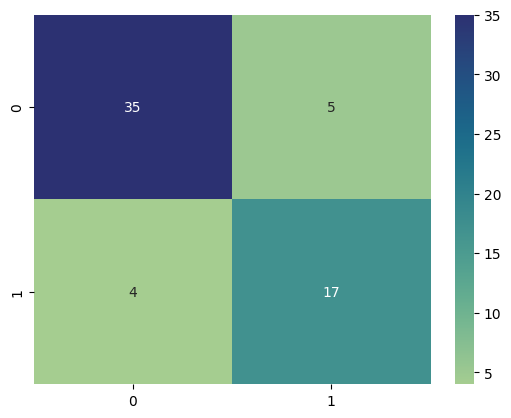

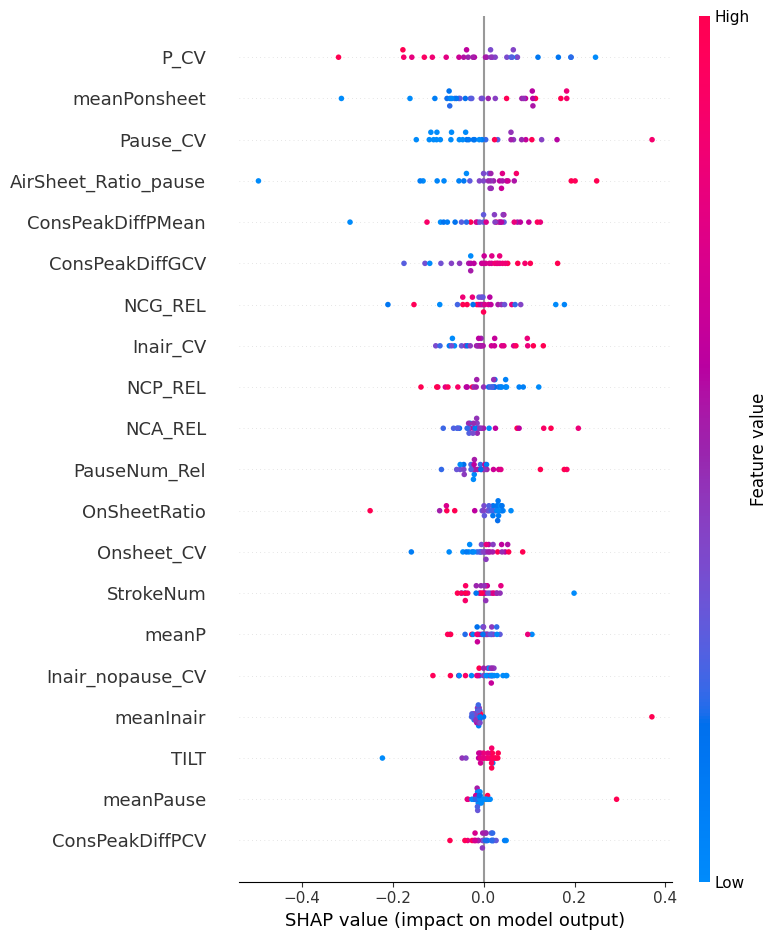

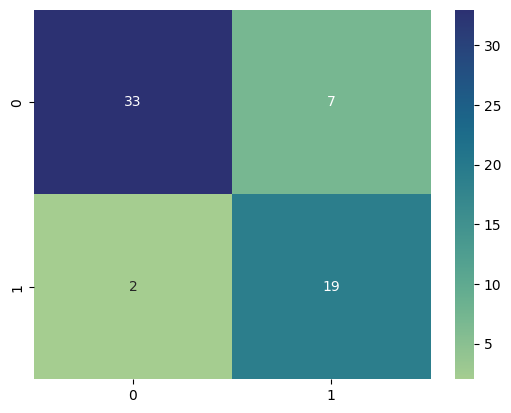

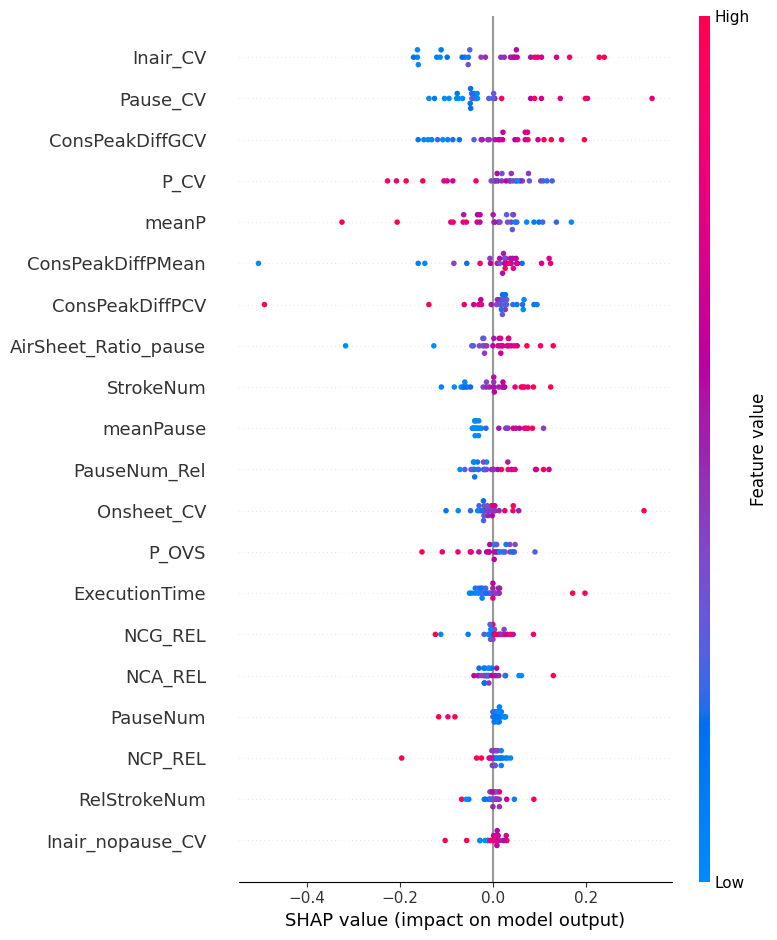

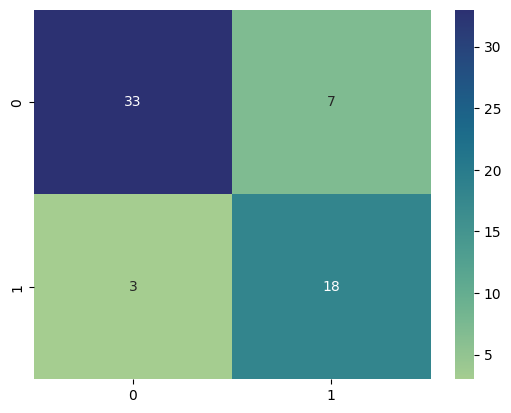

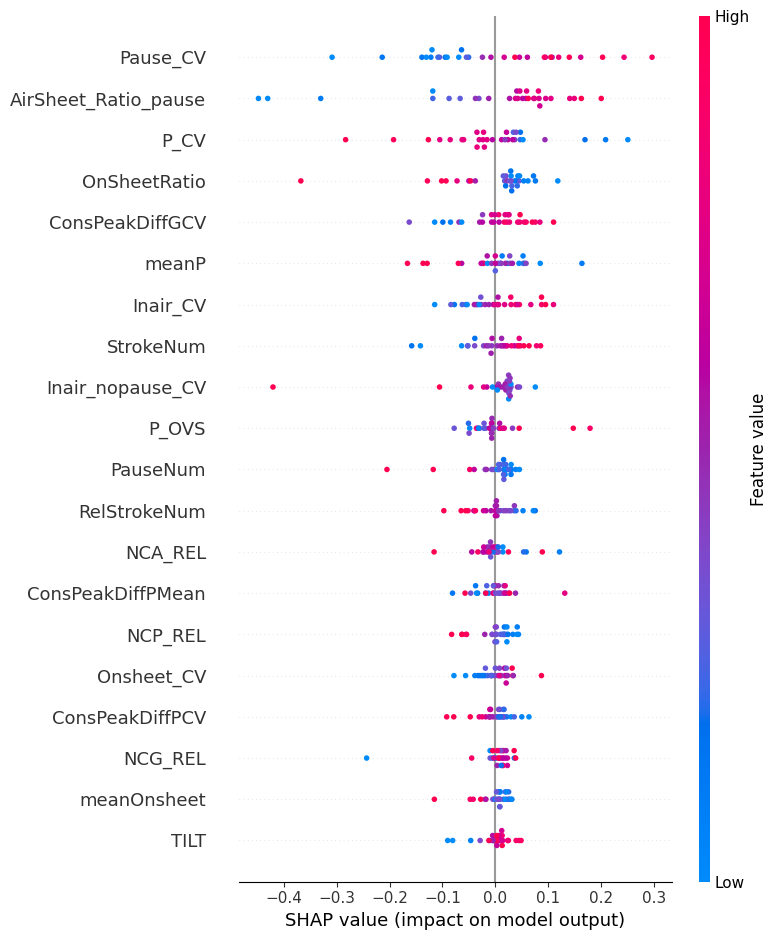

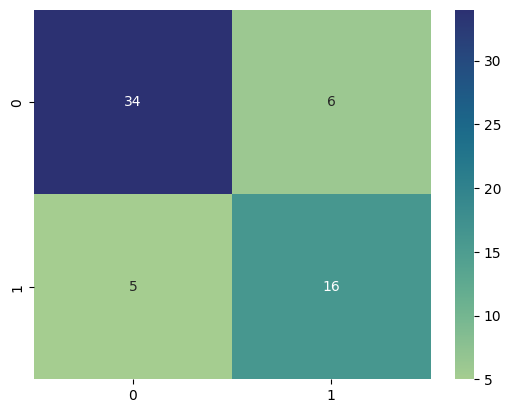

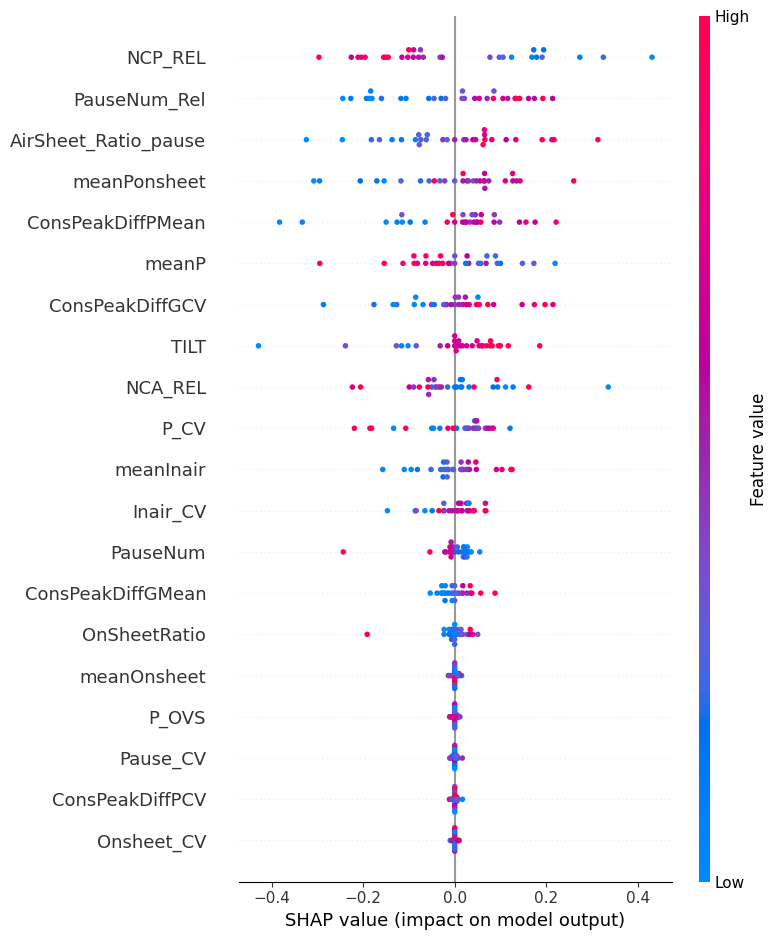

In [ ]:
for seed in seeds:
    if model_type == 'RF':
        model = RandomForestClassifier(random_state=seed, n_jobs=-1)
        gs = GridSearchCV(model, params, cv=5, n_jobs=-1)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)  # these variables are Dataframe objects
    print(f"seed is {seed}; train set shape is {X_train.shape}")

    if resample:
    # random undersampling for unbalanced cases (trough the same seed we always eliminate the same samples of the majority class)
        X_res, y_res = RandomUnderSampler(random_state=seed).fit_resample(X_train, y_train)
        print(f"train set shape after resampling is {X_res.shape}")
    else:
        X_res = X_train
        y_res = y_train

    X_train=scaler.fit_transform(X_res)
    X_test=scaler.transform(X_test)
    y_train = y_res

    X_train_df = pd.DataFrame(X_train, columns = X_res.columns)
    columns_to_check = list(X_res.columns) # it's a list
    selected_features = X_res.columns

    corr_matrix = X_train_df[columns_to_check].corr(method='spearman')
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    high_corr = corr_matrix.mask(mask).stack().reset_index()
    high_corr.columns = ['feature1', 'feature2', 'correlation']
    high_corr = high_corr[(high_corr['correlation'].abs() > corr_threshold) & (high_corr['feature1'] != high_corr['feature2'])]
    print(high_corr)
    X_train_df = X_train_df.drop(high_corr['feature2'], axis=1)
    selected_features = X_train_df.columns
    print(X_train_df.shape)
    print(list(selected_features))

    if model_type == 'Catboost':
        pipeline = Pipeline([
            ('selector', SelectKBest(score_func=f_classif)),
            ('classifier', CatBoostClassifier(random_seed=42, silent=True))
        ])

        param_grid = {
            'selector__k': [5, 10, 15, len(list(selected_features))],
            'classifier__iterations': [100, 200],
            'classifier__depth': [4, 6, 10],
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__l2_leaf_reg': [1, 3, 5, 7]
        }

    if model_type == 'RF':
        pipeline = Pipeline([
            ('selector', SelectKBest(score_func=f_classif)),
            ('classifier', RandomForestClassifier())
        ])

        param_grid = {
            'selector__k': [5, 10, 15, len(list(selected_features))],
            'classifier__n_estimators': [10, 50, 100],
            'classifier__criterion': ['gini', 'entropy'],
            #'classifier__max_depth': [3, 5, 7, 10],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 5],
            'classifier__max_features': ['sqrt', 'log2', None],
            #'classifier__bootstrap': [True, False]
         }

    if model_type == 'SVC':
        pipeline = Pipeline([
            ('selector', SelectKBest(score_func=f_classif)),
            ('classifier', SVC())
        ])

        param_grid = {
            'selector__k': [5, 10, 15, len(list(selected_features))],
            'classifier__C': [0.1, 1, 10, 100],
            'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
            #'classifier__gamma': ['scale', 'auto']
            'classifier__gamma': [0.001,0.01,0.1,1]
        }



    '''
    # feature selection with recursive feature elimination
    model_fs = CatBoostClassifier()
    rfe = RFECV(estimator=model_fs, min_features_to_select=3, step=1, n_jobs=-1)
    rfe.fit(X_train_df, y_res)
    selected_features = X_train_df.columns[rfe.support_]
    print(list(selected_features))
    '''

    X_train = X_train_df.loc[:,selected_features]
    X_test_df = pd.DataFrame(X_test, columns=X_res.columns )
    X_test = X_test_df.loc[:, selected_features]

    maxs = np.array(X_res.max())
    mins = np.array(X_res.min())

    if seed == seeds[-1]:
        print(f"train set shape after resampling and feature selection is {X_train.shape}")
        print(f"test set shape after resampling and feature selection is {X_test.shape}")

    scoring = {
        'accuracy':'accuracy',
        'precision': make_scorer(precision_score),
        'recall': make_scorer(recall_score),
        'f1': make_scorer(f1_score, average='macro'),
        'roc_auc': 'roc_auc'
    }

    gs = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring=scoring, cv=5, n_jobs=-1, verbose=1, refit='f1')
    gs.fit(X_train, y_train)
    best_model = gs.best_estimator_
    y_pred = best_model.predict(X_test)

    val_auc=gs.cv_results_['mean_test_roc_auc'][gs.best_index_]
    val_acc=gs.cv_results_['mean_test_accuracy'][gs.best_index_]
    val_prec=gs.cv_results_['mean_test_precision'][gs.best_index_]
    val_recall= gs.cv_results_['mean_test_recall'][ gs.best_index_]
    val_f1=gs.cv_results_['mean_test_f1'][gs.best_index_]
    std_acc= gs.cv_results_['std_test_accuracy'][gs.best_index_]
    std_auc= gs.cv_results_['std_test_roc_auc'][gs.best_index_]
    std_prec= gs.cv_results_['std_test_precision'][gs.best_index_]
    std_recall= gs.cv_results_['std_test_recall'][gs.best_index_]
    std_f1= gs.cv_results_['std_test_f1'][gs.best_index_]


    print('***RESULTS ON VALIDATION SET***')
    print('\nAccuracy: %.3f (%.3f)' % (val_acc, std_acc))
    print('Precision: %.3f (%.3f)' % (val_prec, std_prec))
    print('Recall: %.3f (%.3f)' % (val_recall, std_recall))
    print('F1 Score: %.3f (%.3f)' % (val_f1, std_f1))
    print('ROC-AUC: %.3f (%.3f)' % (val_auc, std_auc))

    print('***RESULTS ON TEST SET***')
    print('Accuracy: ', accuracy_score(y_test, y_pred))
    print('Precision: ', precision_score(y_test, y_pred))
    print('Recall: ', recall_score(y_test, y_pred))
    print('F1: ', f1_score(y_test, y_pred))
    print('ROC-AUC: ', roc_auc_score(y_test, y_pred))

    cm = confusion_matrix(y_true=y_test, y_pred=y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, cmap="crest")


    print(gs.best_params_)


    performance = pd.DataFrame([[val_acc, std_acc, accuracy_score(y_test, y_pred)],
                           [val_prec, std_prec, precision_score(y_test, y_pred)],
                           [val_recall, std_recall, recall_score(y_test, y_pred)],
                           [val_f1, std_f1, f1_score(y_test, y_pred)],
                           [val_auc, std_auc, roc_auc_score(y_test, y_pred)]],
                           index=['accuracy', 'precision', 'recall', 'f1', 'ROC-AUC'],
                           columns=['MeanTrain', 'StdTrain', 'Test'])

    common_name_part = model_type + '_' + model_name + '_' + task + '_SamplexSubj' + str(num_pilot_data) + '_seed' + str(seed)
    if model_type == 'Catboost':
        #best_model.save_model(save_folder_path + '/' + common_name_part)
        best_model.named_steps['classifier'].save_model(save_folder_path + '/' + common_name_part)
    else:
        dump(best_model,save_folder_path + '/' + common_name_part + '.joblib')

    np.save(save_folder_path + '/maxs_' + common_name_part + '.npy', maxs)
    np.save(save_folder_path + '/mins_' + common_name_part + '.npy', mins)

    excel_filename = save_folder_path + '/' + model_type + '_' + model_name + '_' + task + '_SamplexSubj' + str(num_pilot_data) + '.xlsx'
    if os.path.isfile(excel_filename):
     with pd.ExcelWriter(excel_filename, engine = 'openpyxl', mode = 'a') as writer:
         performance.to_excel(writer,sheet_name=str(seed))
    else:
     performance.to_excel(excel_filename,sheet_name=str(seed))

    if model_type == 'Catboost':
     f = lambda x: best_model.predict(x)
     explainer = shap.KernelExplainer(f, shap.sample(X_train,K))
     shap_values = explainer.shap_values(X_train, check_additivity=False)
    else:
     f = lambda x: best_model.predict(x)
     explainer = shap.KernelExplainer(f, shap.sample(X_train,K))
     shap_values = explainer.shap_values(shap.sample(X_train,K))


    shap.initjs()
    plt.figure()
    plt.grid(False)

    if model_type == 'Catboost': # summary plot for model other than catboost
        shap.summary_plot(shap_values, X_train, feature_names=list(X.columns), show=False)

    else:  # summary plot for SVC e RT
        shap.summary_plot(shap_values, shap.sample(X_train,K), feature_names=list(X.columns), show=False)

    f= plt.gcf()
    f.savefig(save_folder_path + '/' + common_name_part + '_shap.png')




In [ ]:
for seed in seeds:
  if model_type == 'RF':
    model = RandomForestClassifier(random_state=seed, n_jobs=-1)
    gs = GridSearchCV(model, params, cv=5, refit='f1', n_jobs=-1, scoring=scoring)

  #train-test split
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
  print(f"seed is {seed}; train set shape is {X_train.shape}:")

  if resample:
    #random undersampler for unbalanced cases
    X_res, y_res = RandomUnderSampler(random_state=seed).fit_resample(X_train, y_train)
    print(f"train set shape after resampling is {X_res.shape}")
  else:
     X_res = X_train
     y_res = y_train


  #scale train and test data according to train data
  X_train=scaler.fit_transform(X_res)
  X_test=scaler.transform(X_test)
  y_train = y_res
  #print(np.unique(y_res, return_counts=True))

  #create train dataframe after undersampling and scaling
  X_train_df = pd.DataFrame(X_train, columns = X_res.columns)
  columns_to_check = list(X_res.columns) # it's a list
  selected_features = X_res.columns # it's an object

  # if you want to remove highly correlated features, according to corr_threshold

  corr_matrix = X_train_df[columns_to_check].corr(method='spearman')
  mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
  # Identify the highly correlated features
  high_corr = corr_matrix.mask(mask).stack().reset_index()
  high_corr.columns = ['feature1', 'feature2', 'correlation']
  high_corr = high_corr[(high_corr['correlation'].abs() > corr_threshold) & (high_corr['feature1'] != high_corr['feature2'])]
  print(high_corr)
  #%%
  X_train_df = X_train_df.drop(high_corr['feature2'], axis=1)
  selected_features = X_train_df.columns
  #%%
  print(X_train_df.shape)
  print(list(selected_features))



  '''
  # if you want to perform feature selection
  model_fs = CatBoostClassifier()
  rfe = RFECV(estimator=model_fs, min_features_to_select=30, step=1, n_jobs=-1)
  rfe.fit(X_train_df, y_res)
  selected_features = X_train_df.columns[rfe.support_]
  print(selected_features)
  '''

  # select only features of interest for train set
  X_train = X_train_df.loc[:,selected_features]


  # select only features of interest for test set
  X_test_df = pd.DataFrame(X_test, columns=X_res.columns )
  X_test = X_test_df.loc[:, selected_features]
  #print(X_test.columns)


  #extract maximum and minimum for each feature
  maxs = np.array(X_res.max())
  mins = np.array(X_res.min())

  if seed == seeds[-1]:
    print(f"train set shape after resampling and feature selection is {X_train.shape}")
    print(f"test set shape after resampling and feature selection is {X_test.shape}")

  # fit grid search with train data and find best model on training set
  # gs.fit(X_train, y_train)
  # best_model = gs.best_estimator_

  #PROVA DIMENSIONALITY REDUCTION
  gs = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)
  gs.fit(X_train, y_train)
  best_model = gs.best_estimator_
  y_pred = best_model.predict(X_test)

  # save performance metrics of best model on training set
  #val_acc=gs.cv_results_['mean_test_accuracy'][gs.best_index_]
  val_auc=gs.cv_results_['mean_test_roc_auc'][gs.best_index_]
  val_prec=gs.cv_results_['mean_test_precision'][gs.best_index_]
  val_recall= gs.cv_results_['mean_test_recall'][ gs.best_index_]
  val_f1=gs.cv_results_['mean_test_f1'][gs.best_index_]
  std_acc= gs.cv_results_['std_test_accuracy'][gs.best_index_]
  std_auc= gs.cv_results_['std_test_roc_auc'][gs.best_index_]
  std_prec= gs.cv_results_['std_test_precision'][gs.best_index_]
  std_recall= gs.cv_results_['std_test_recall'][gs.best_index_]
  std_f1= gs.cv_results_['std_test_f1'][gs.best_index_]

  # print performance metrics of best model on training set
  print('***RESULTS ON VALIDATION SET***')
  print('\nAccuracy: %.3f (%.3f)' % (val_acc, std_acc))
  print('Precision: %.3f (%.3f)' % (val_prec, std_prec))
  print('Recall: %.3f (%.3f)' % (val_recall, std_recall))
  print('F1 Score: %.3f (%.3f)' % (val_f1, std_f1))
  print('ROC-AUC: %.3f (%.3f)' % (val_auc, std_auc))

  # use best model on training set and plot performance metrics
  #y_pred = best_model.predict(X_test)
  print('***RESULTS ON TEST SET***')
  print('Accuracy: ', accuracy_score(y_test, y_pred))
  print('Precision: ', precision_score(y_test, y_pred))
  print('Recall: ', recall_score(y_test, y_pred))
  print('F1: ', f1_score(y_test, y_pred))
  print('ROC-AUC: ', roc_auc_score(y_test, y_pred))

  # create test set confusion matrix
  cm = confusion_matrix(y_true=y_test, y_pred=y_pred)
  plt.figure()
  sns.heatmap(cm, annot=True, cmap="crest")

  # print best parameters combination
  print(gs.best_params_)

  # save train and test metrics in dataframe
  performance = pd.DataFrame([[val_acc, std_acc, accuracy_score(y_test, y_pred)],
                           [val_prec, std_prec, precision_score(y_test, y_pred)],
                           [val_recall, std_recall, recall_score(y_test, y_pred)],
                           [val_f1, std_f1, f1_score(y_test, y_pred)],
                           [val_auc, std_auc, roc_auc_score(y_test, y_pred)]],
                           index=['accuracy', 'precision', 'recall', 'f1', 'ROC-AUC'],
                           columns=['MeanTrain', 'StdTrain', 'Test'])

  # save results in save folder
  # save models, maxs and mins
  common_name_part = model_type + '_' + model_name + '_' + task + '_SamplexSubj' + str(num_pilot_data) + '_seed' + str(seed)
  if model_type == 'Catboost':
    best_model.save_model(save_folder_path + '/' + common_name_part)
  else:
    dump(best_model,save_folder_path + '/' + common_name_part + '.joblib')

  np.save(save_folder_path + '/maxs_' + common_name_part + '.npy', maxs)
  np.save(save_folder_path + '/mins_' + common_name_part + '.npy', mins)
  # save performance in excel
  excel_filename = save_folder_path + '/' + model_type + '_' + model_name + '_' + task + '_SamplexSubj' + str(num_pilot_data) + '.xlsx'
  if os.path.isfile(excel_filename):
    with pd.ExcelWriter(excel_filename, engine = 'openpyxl', mode = 'a') as writer:
         performance.to_excel(writer,sheet_name=str(seed))
  else:
    performance.to_excel(excel_filename,sheet_name=str(seed))

  #SHAP ANALYSIS

  if model_type == 'Catboost':
     explainer = shap.TreeExplainer(best_model, X_train)
     shap_values = explainer.shap_values(X_train, check_additivity=False)
  else:
     explainer = shap.KernelExplainer(best_model.predict, shap.sample(X_train,K))
     shap_values = explainer.shap_values(shap.sample(X_train,K))


  shap.initjs()
  plt.figure()
  plt.grid(False)


  if model_type == 'Catboost': # summary plot for model other than catboost
    shap.summary_plot(shap_values, X_train, feature_names=list(X.columns), show=False)

  else:  # summary plot for SVC e RT
    shap.summary_plot(shap_values, shap.sample(X_train,K), feature_names=list(X.columns), show=False)

  f= plt.gcf()
  f.savefig(save_folder_path + '/' + common_name_part + '_shap.png')

seed is 0; train set shape is (300, 32):
train set shape after resampling is (196, 32)
         feature1      feature2  correlation
5     meanOnsheet  RelStrokeNum    -0.971517
7    OnSheetRatio     StrokeNum    -0.969574
34       PauseNum     meanPause     0.991375
42   PauseNum_Rel     meanPause     0.988419
44   PauseNum_Rel      PauseNum     0.997554
65          meanP  meanPonsheet     0.978219
275      TILT_VAR       TILT_CV     0.962365
464  S45_median_s   S4_median_s     0.964525
(196, 25)
['ExecutionTime', 'meanOnsheet', 'OnSheetRatio', 'Inair_nopause_CV', 'Pause_CV', 'PauseNum_Rel', 'meanP', 'P_CV', 'P_OVS', 'NCP_REL', 'NCG_REL', 'NCA_REL', 'ConsPeakDiffPMean', 'ConsPeakDiffPCV', 'ConsPeakDiffGMean', 'ConsPeakDiffGCV', 'TILT', 'TILT_VAR', 'LDLJ_A_median', 'LDLJ_G_median', 'S1_median_s', 'S2_median_s', 'S3_median_s', 'S45_median_s', 'S5_median_s']
Fitting 5 folds for each of 32 candidates, totalling 160 fits


KeyError: 'mean_test_roc_auc'